In [4]:
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
#Cas n°1 : Ici l'économie se déroule dans un environnement libre et stable, les agents sont rationnels, l'information est parfaite et il n'y a pas d'impact ni d'influence d'acteurs exterieurs (état etc..)
#il n'y a donc pas non plus de régulation ni d'intervention étatique et ni de bulles speculatives

In [6]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.8
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.2<1:
               vecteur.append(e*1.2)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.6])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat, liste):
    """fonction qui calcule l'indice global du marché en fonction de l'état du marché et du nombre d'investisseurs"""
    res = 0
    print(vecteurindice)
    for i in range(len(vecteurindice)):
        res = 0
        if etat == 0:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(-0.02, 0.00001)          #on simplifie, tous les prix diminuent lors d'une crise
            #print(res)
            vecteurindice[i] += res

        if etat == 2:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0.05, 0.00001)
            vecteurindice[i] += res

        if etat == 1:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0, 0.00001)
            vecteurindice[i] += res
    nv_indice = np.mean(vecteurindice) 
    liste.append(nv_indice)
    return nv_indice



def probamatrice(matrice,etat, indice1, indice0, epsilon): 
    variation = (indice1 -indice0)/indice0
    sensibilité = epsilon

    if variation > 0:
        transfert = min(matrice[etat][0], abs(sensibilité*variation))
        matrice[etat][0] -= transfert 
        matrice[etat][2] += transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
    
    elif variation < 0:
        transfert = min(matrice[etat][2], abs(sensibilité*variation))
        matrice[etat][0] += transfert
        matrice[etat][2] -= transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]     
    
    return matrice


In [7]:

def fonction_cas1(matrice, etat, vecteurpopulation, vecteurindice):
    nvetat = 0
    vecteur_indices = [1]
    matrice_pop = []
    vecteur_etats = [etat]
    
    for i in range(5):
        nvetat = passage(matrice, etat)

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = prop_investisseurs(nvetat)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat, vecteur_indices)

        matrice = probamatrice(matrice, nvetat, vecteur_indices[i], vecteur_indices[i+1], 0.1)

        vecteur_etats.append(nvetat)
        etat = nvetat
    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop

    

In [11]:
#variables exogènes

indice0 = 1
population = 1000
titres = 25
res = [indice0]
matrice = [[0.7, 0.2, 0.1], [0.3, 0.4, 0.3], [0.1, 0.2, 0.7]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation = np.random.normal(0.5, 0.15, population) 
# vecteur contenant toutes les opinions de la population, aux extremes on a des gens qui investissent beaucoup ou peu les valeurs sont comprises entre 0 et 1

vecteurindices = np.array([np.random.uniform()*10 for _ in range(titres)])
#vecteur contenant tous les indices de prix  l'indice positif veut dire que les prix ont globalement augmenté, l'indice négatif veut dire que les prix ont globalement diminué
#les prix sont tirés aléatoirement entre 0 et 10 le choix de l'encadrement est arbitraire, on peut le changer

In [12]:
k = fonction_cas1(matrice, 0, vecteurpopulation, vecteurindices)

[1.39962159 8.35658595 3.79819989 9.42292379 3.05793568 5.06904083
 7.70268543 5.27115802 5.74655034 8.04890794 3.97949243 4.20353798
 5.22283794 4.95718611 7.56815558 3.20260762 3.38399636 0.85314226
 3.2692765  5.6884069  4.46456337 8.55450224 7.00797131 4.56547325
 8.10695145]
[-3.82058891e+00  3.13656117e+00 -1.42187190e+00  4.20294056e+00
 -2.16222657e+00 -1.51148770e-01  2.48278267e+00  5.11614779e-02
  5.26452334e-01  2.82875919e+00 -1.24036134e+00 -1.01645988e+00
  2.62668022e-03 -2.62980391e-01  2.34821491e+00 -2.01744436e+00
 -1.83607545e+00 -4.36689355e+00 -1.95079585e+00  4.68126393e-01
 -7.55297119e-01  3.33449386e+00  1.78802189e+00 -6.54649590e-01
  2.88709201e+00]
[33.57923583 40.53655241 35.97797284 41.60289388 35.23765081 37.24870223
 39.88238399 37.45089178 37.9266401  40.22920534 36.16009017 36.38332566
 37.40226175 37.13654023 39.74811295 35.38282848 35.56422441 33.03305706
 35.44948196 37.86771831 36.64450958 40.73474991 39.18826463 36.74514911
 40.28764703]
[70.9

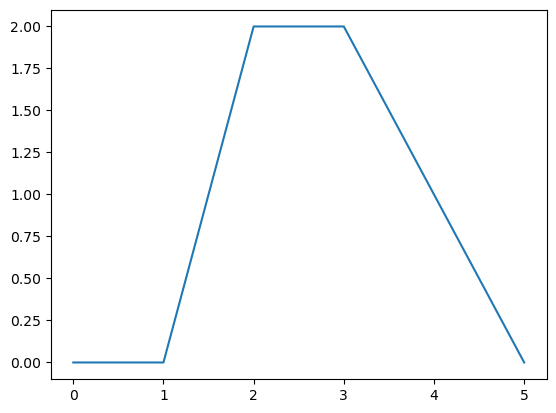

In [13]:
abscisse = np.arange(0, len(k[1]), 1)
plt.plot(abscisse, k[1])